%pip install -U -q numpy pandas wfdb matplotlib notebook scikit-learn PyWavelets

import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

#MAJA I MANIA DETEKCJA EVENTÓW

In [34]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Sekcja wczytwania


Uruchamiam przetwarzanie wektorowe Pandas...

 PODSUMOWANIE ANALIZY DLA REKORDU: charis13
  * Czas trwania sygnału: 284399.12 s (79.00 h)
  * Liczba wszystkich wykrytych zdarzeń (eventów): 5
  * Liczba wyekstrahowanych segmentów klinicznych: 1



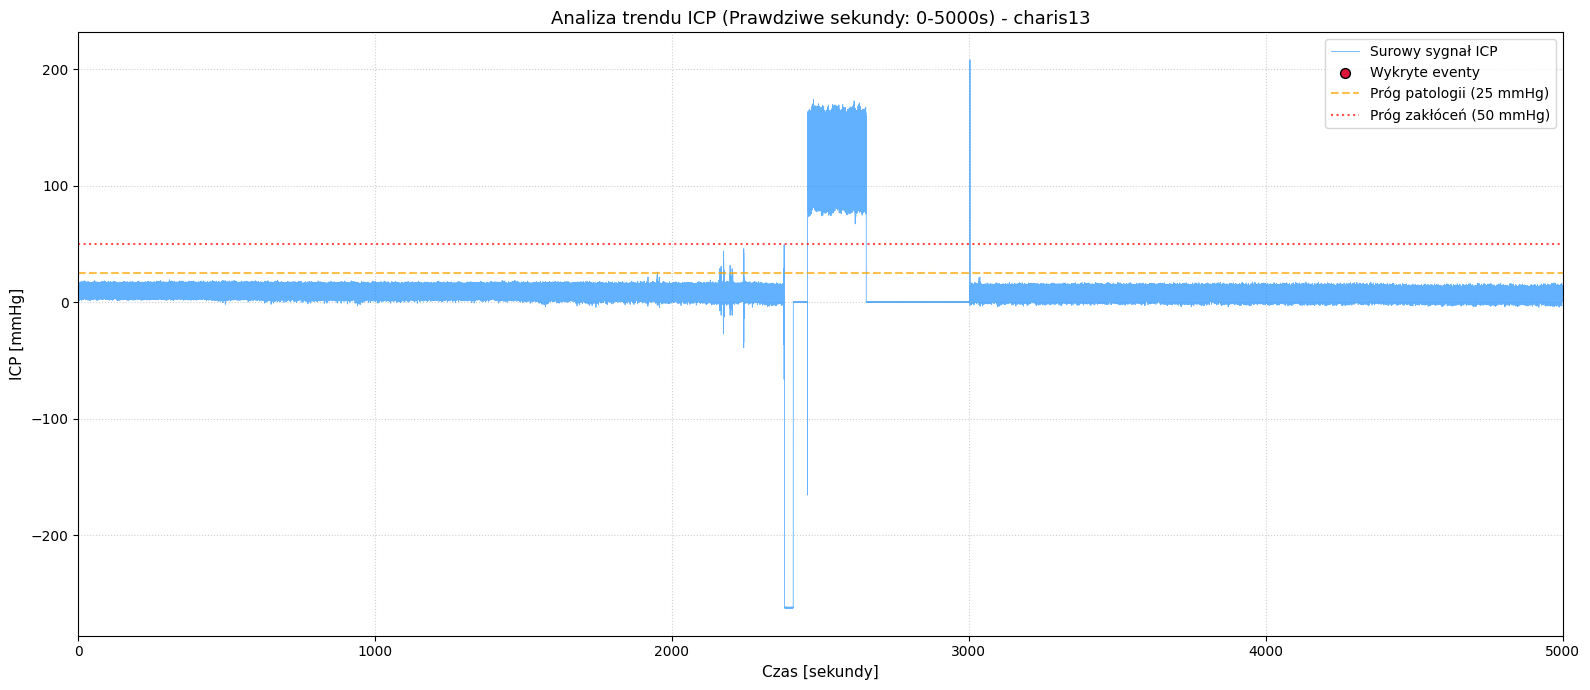

In [35]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ICP_ABP_Processor:
    def __init__(self, channel_icp, channel_abp, sampling_freq):
        self.channel_icp = channel_icp
        self.channel_abp = channel_abp
        self.fs = sampling_freq
        
        class SignalWrapper:
            def __init__(self, data): self.data = data
        self.icp = SignalWrapper(channel_icp)
        self.abp = SignalWrapper(channel_abp)
        
        self.final_segments = []
        self.df = None
        self.total_events_count = 0  # Licznik wszystkich eventów

    def process_all(self, record_name):
        print("Uruchamiam przetwarzanie wektorowe Pandas...")
        
        # Obliczanie długości sygnału w sekundach i godzinach
        total_samples = len(self.channel_icp)
        total_seconds = total_samples / self.fs
        total_hours = total_seconds / 3600
        
        # 1. Podział na minuty i uśrednianie (Etapy 1-3)
        samples_per_min = int(self.fs * 60)
        full_mins = total_samples // samples_per_min
        
        icp_matrix = self.channel_icp[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        abp_matrix = self.channel_abp[:full_mins * samples_per_min].reshape(full_mins, samples_per_min)
        
        self.df = pd.DataFrame({
            'MICP': icp_matrix.mean(axis=1),
            'MABP': abp_matrix.mean(axis=1)
        })
        
        # 2. Usuwanie zakłóceń (Etap 4: >50 mmHg)
        self.df['is_valid'] = self.df['MICP'] <= 50
        
        # 3. Detekcja zdarzeń (Etap 5: >25 mmHg przez min. 5 min)
        self.df['event_condition'] = self.df['is_valid'] & (self.df['MICP'] > 25)
        self.df['block_id'] = (~self.df['event_condition']).cumsum()
        
        event_blocks = self.df[self.df['event_condition']].groupby('block_id').size()
        valid_event_blocks = event_blocks[event_blocks >= 5].index
        
        # ZAPISUJEMY CAŁKOWITĄ LICZBĘ EVENTÓW
        self.total_events_count = len(valid_event_blocks)
        
        # Flagowanie minut do wykresu
        self.df['is_event'] = self.df['event_condition'] & self.df['block_id'].isin(valid_event_blocks)
        
        # 4. Podział na segmenty z 1h czystego sygnału przed (Etap 6)
        for block in valid_event_blocks:
            event_minutes = self.df[(self.df['block_id'] == block) & self.df['event_condition']].index
            event_start = event_minutes.min()
            event_end = event_minutes.max()
            
            if event_start >= 60:
                pre_event_window = self.df.loc[event_start - 60 : event_start - 1, 'is_valid']
                if pre_event_window.all():
                    self.final_segments.append({
                        'pre_event_start_min': event_start - 60,
                        'event_start_min': event_start,
                        'event_end_min': event_end,
                        'duration_min': (event_end - event_start) + 1
                    })
                    
        # WYŚWIETLENIE SYNTETYCZNYCH WYNIKÓW (Z DODANYM CZASEM TRWANIA)
        print("\n" + "="*50)
        print(f" PODSUMOWANIE ANALIZY DLA REKORDU: {record_name}")
        print("="*50)
        print(f"  * Czas trwania sygnału: {total_seconds:.2f} s ({total_hours:.2f} h)")
        print(f"  * Liczba wszystkich wykrytych zdarzeń (eventów): {self.total_events_count}")
        print(f"  * Liczba wyekstrahowanych segmentów klinicznych: {len(self.final_segments)}")
        print("="*50 + "\n")


# =========================================================================
# URUCHOMIENIE
# =========================================================================
data_dir = 'charis-database-1.0.0'  
record_name = 'charis13'             

os.makedirs(data_dir, exist_ok=True)
local_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(local_path)
signals = record.p_signal  
fs = record.fs  

channel_ABP = signals[:, 0]
channel_ICP = signals[:, 2]

processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=fs)
processor.process_all(record_name)

# =========================================================================
# CAŁKOWICIE POPRAWIONY WYKRES (PRAWDZIWE SEKUNDY I PRECYZYJNE EVENTY)
# =========================================================================
plt.figure(figsize=(16, 7))

# 1. Rysujemy surowy sygnał sekunda po sekundzie (korzystamy z wektora time i pierwotnego kanału)
max_seconds = 5000
plt.plot(time[:int(max_seconds * fs)], channel_ICP[:int(max_seconds * fs)], 
         label='Surowy sygnał ICP', color='dodgerblue', linewidth=0.6, alpha=0.7)

# 2. Generujemy wektor sekundowy dla eventów, żeby kółeczka idealnie trafiały w punkty
# Tworzymy maskę sekundową: rozciągamy minuty z 'is_event' z powrotem na pojedyncze sekundy
event_mask_seconds = np.repeat(processor.df['is_event'].values, int(fs * 60))

# Przycinamy maskę do długości naszego fragmentu 5000 sekund
event_mask_filtered = event_mask_seconds[:int(max_seconds * fs)]
time_filtered = time[:int(max_seconds * fs)]
signal_filtered = channel_ICP[:int(max_seconds * fs)]

# 3. Nakładamy czerwone kółeczka wyłącznie w sekundy, w których trwa event
# Żeby wykres nie był przeładowany (bo fs=50Hz dałoby 50 kółeczek na sekundę), 
# rysujemy kółeczko np. raz na sekundę (co fs-tą próbkę)
plt.scatter(time_filtered[event_mask_filtered][::int(fs)], 
            signal_filtered[event_mask_filtered][::int(fs)], 
            color='crimson', marker='o', s=50, edgecolor='black', zorder=3, label='Wykryte eventy')

# Progi kontrolne
plt.axhline(y=25, color='orange', linestyle='--', alpha=0.7, label='Próg patologii (25 mmHg)')
plt.axhline(y=50, color='red', linestyle=':', alpha=0.7, label='Próg zakłóceń (50 mmHg)')

# Ustawienia osi i stylu
plt.xlim(0, max_seconds)
plt.title(f'Analiza trendu ICP (Prawdziwe sekundy: 0-{max_seconds}s) - {record_name}', fontsize=13)
plt.xlabel('Czas [sekundy]', fontsize=11)
plt.ylabel('ICP [mmHg]', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd


def detect_icp_events(
    df, icp_col="ICP", prx_col="PRx", fs_icp=1, var_threshold=5.0
):
    """Automatyczna detekcja zdarzeń ICP na podstawie wytycznych z artykułu.

    df: DataFrame zawierający kolumny z czasem, ICP oraz PRx
    fs_icp: częstotliwość próbkowania ICP w Hz (np. 1 Hz = 1 próbka na sekundę)
    var_threshold: próg wariancji sygnału akceptujący zdarzenie
    """

    # 1. Obliczanie 1-minutowej średniej kroczącej (60 sekund)
    window_1min = 60 * fs_icp
    df["ICP_mean_1min"] = (
        df[icp_col].rolling(window=window_1min, center=False).mean()
    )

    # Obliczenie wariancji (używanej jako kryterium akceptacji)
    df["ICP_var"] = (
        df[icp_col].rolling(window=window_1min, center=False).var()
    )

    # 2. Synchronizacja PRx (PRx spóźnia się o 305 sekund, więc przesuwamy go W TYŁ, aby wyrównać z ICP)
    # Przesunięcie o 305 sekund: shift(-305) dopasuje dane PRx do real-time ICP
    shift_samples = 305 * fs_icp
    df["PRx_synced"] = df[prx_col].shift(-shift_samples)

    events_indices = []
    window_1h = 3600 * fs_icp  # 1 godzina w próbkach

    # Przeszukujemy dane (zaczynamy po 1 godzinie, żeby móc zbadać okres "quiet")
    for i in range(window_1h, len(df)):
        # Przykładowe proste kryterium wzrostu ICP (np. skok o 50% powyżej normy lub przekroczenie progu)
        # W artykule kryteria doboru "kandydatów" zależały od ich własnych stałych medycznych
        is_candidate = (
            df["ICP_mean_1min"].iloc[i] > 25
        )  # Przykladowy próg patologiczny > 25 mmHg

        if is_candidate:
            # Sprawdzenie wariancji (kryterium akceptacji szumów/artefaktów)
            if df["ICP_var"].iloc[i] < var_threshold:

                # 3. Warunek "Quiet Period" – co najmniej 1 godzina stabilnego, prawidłowego ciśnienia wstecz
                previous_hour_icp = df["ICP_mean_1min"].iloc[
                    i - window_1h : i
                ]
                is_quiet_normotensive = np.all(
                    previous_hour_icp < 15
                )  # Normotensja: < 15 mmHg przez całą godzinę

                if is_quiet_normotensive:
                    # Sprawdzamy, czy to początek zdarzenia (unikamy dublowania klatek obok siebie)
                    if len(events_indices) == 0 or (
                        i - events_indices[-1] > window_1min
                    ):
                        events_indices.append(i)

    # Zwracamy indeksy wykrytych zdarzeń oraz przetworzony DataFrame
    return events_indices, df


# --- PRZYKŁAD UŻYCIA (Sztuczne dane do testu) ---
if __name__ == "__main__":
    print("Generowanie testowego szeregu czasowego...")
    # Tworzymy 5 godzin danych próbkowanych co 1 sekundę (1Hz)
    num_samples = 5 * 3600
    timestamps = pd.date_range(
        start="2026-01-01", periods=num_samples, freq="1s"
    )

    # Generujemy stabilne ICP (ok. 10 mmHg) z szumem
    icp_data = np.random.normal(loc=10, scale=1, size=num_samples)
    # Wstrzykujemy jedno sztuczne "zdarzenie patologiczne" w 4. godzinie (indeks 14400)
    icp_data[14400 : 14400 + 300] += 20

    # Tworzymy przesunięty sygnał PRx
    prx_data = np.random.normal(loc=0.1, scale=0.05, size=num_samples)

    mock_df = pd.DataFrame(
        {"Timestamp": timestamps, "ICP": icp_data, "PRx": prx_data}
    )

    # Uruchomienie algorytmu
    events, processed_df = detect_icp_events(mock_df, fs_icp=1)

    print(f"Liczba wykrytych zdarzeń: {len(events)}")
    for idx in events:
        print(f"Zdarzenie wykryte o godzinie: {processed_df['Timestamp'].iloc[idx]}")

Generowanie testowego szeregu czasowego...
Liczba wykrytych zdarzeń: 0
